# 4. Fraktalne Funkcje Interpolacyjne (FIF)

## Wprowadzenie

**Fraktalne funkcje interpolacyjne** (Fractal Interpolation Functions, FIF) to metoda interpolacji danych, która generuje funkcje z fraktalną strukturą między punktami interpolacji.

### Podstawy teoretyczne

FIF są konstruowane przy użyciu **Iterated Function Systems (IFS)** - systemów iterowanych funkcji. Każda FIF jest attraktorem pewnego IFS.

### Kluczowe cechy FIF:
1. Funkcja przechodzi przez wszystkie punkty interpolacji
2. Struktura między punktami jest samopodobna
3. „Szorstkość” wykresu zależy od **pionowych współczynników skalowania** $d_i$

### Wymiar fraktalny wykresu FIF (box/Minkowski)

Interesuje nas wymiar wykresu $\Gamma(f)\subset\mathbb{R}^2$.

Niech $a_i = \frac{x_i-x_{i-1}}{x_n-x_0}$ będzie poziomym skurczem dziedziny na segmencie $i$.
Wtedy:

- jeśli $\sum_i |d_i| \le 1$, to $D = 1$,
- jeśli $\sum_i |d_i| > 1$, to $D\in(1,2)$ jest jedynym rozwiązaniem równania

$$\sum_i |d_i|\, a_i^{D-1} = 1.$$

W szczególnym przypadku węzłów równoodległych ($a_i=1/n$) dostajemy klasyczny wzór:

$$D = 1 + \frac{\log\left(\sum_i |d_i|\right)}{\log n}.$$

In [36]:
# Importy
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, '..')

from src.fractal_interpolation import simple_fif, fif_dimension_theoretical
from src.box_counting import curve_to_points, box_counting_dimension

# Konfiguracja
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print("Moduły załadowane pomyślnie!")

Moduły załadowane pomyślnie!


## 4.1 Podstawowa konstrukcja FIF

Zacznijmy od prostego przykładu z trzema punktami interpolacji.

In [37]:
# Punkty interpolacji
data_points = np.array([
    [0.0, 0.0],
    [0.5, 1.0],
    [1.0, 0.0]
])

print("Punkty interpolacji:")
for i, (x, y) in enumerate(data_points):
    print(f"  P{i}: ({x}, {y})")

Punkty interpolacji:
  P0: (0.0, 0.0)
  P1: (0.5, 1.0)
  P2: (1.0, 0.0)


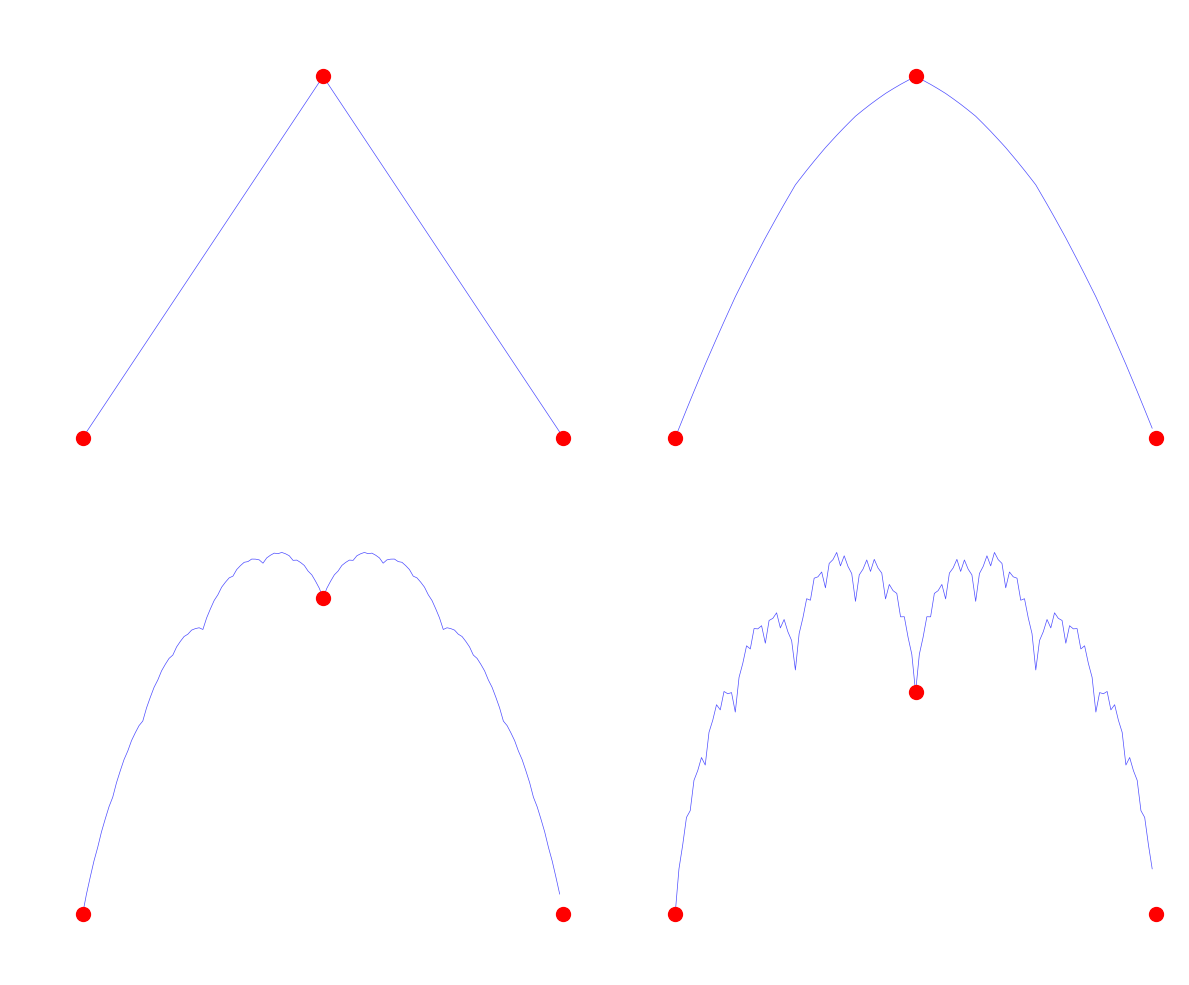

In [38]:
# FIF dla różnych współczynników skalowania
d_values = [0.0, 0.2, 0.4, 0.6]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, d in zip(axes.flat, d_values):
    if d == 0:
        # Interpolacja liniowa (d = 0)
        x = np.linspace(0, 1, 1000)
        y = np.interp(x, data_points[:, 0], data_points[:, 1])
        label = "Interpolacja liniowa"
    else:
        x, y = simple_fif(data_points, d=d, n_iterations=7)
        label = f"FIF (d = {d})"
    
    ax.plot(x, y, 'b-', linewidth=0.5, alpha=0.7)
    ax.scatter(data_points[:, 0], data_points[:, 1], c='red', s=100, zorder=5)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_title(label)

plt.suptitle('Fraktalne funkcje interpolacyjne dla różnych współczynników skalowania', fontsize=14)
plt.tight_layout()
plt.savefig('../output/figures/fif_basic.png', dpi=150)
plt.show()

## 4.2 Wpływ współczynnika skalowania d

Współczynnik skalowania $d$ kontroluje "szorstkość" funkcji:
- $d = 0$: interpolacja liniowa (wymiar = 1)
- $|d| \to 1$: coraz bardziej fraktalna struktura (wymiar → 2)

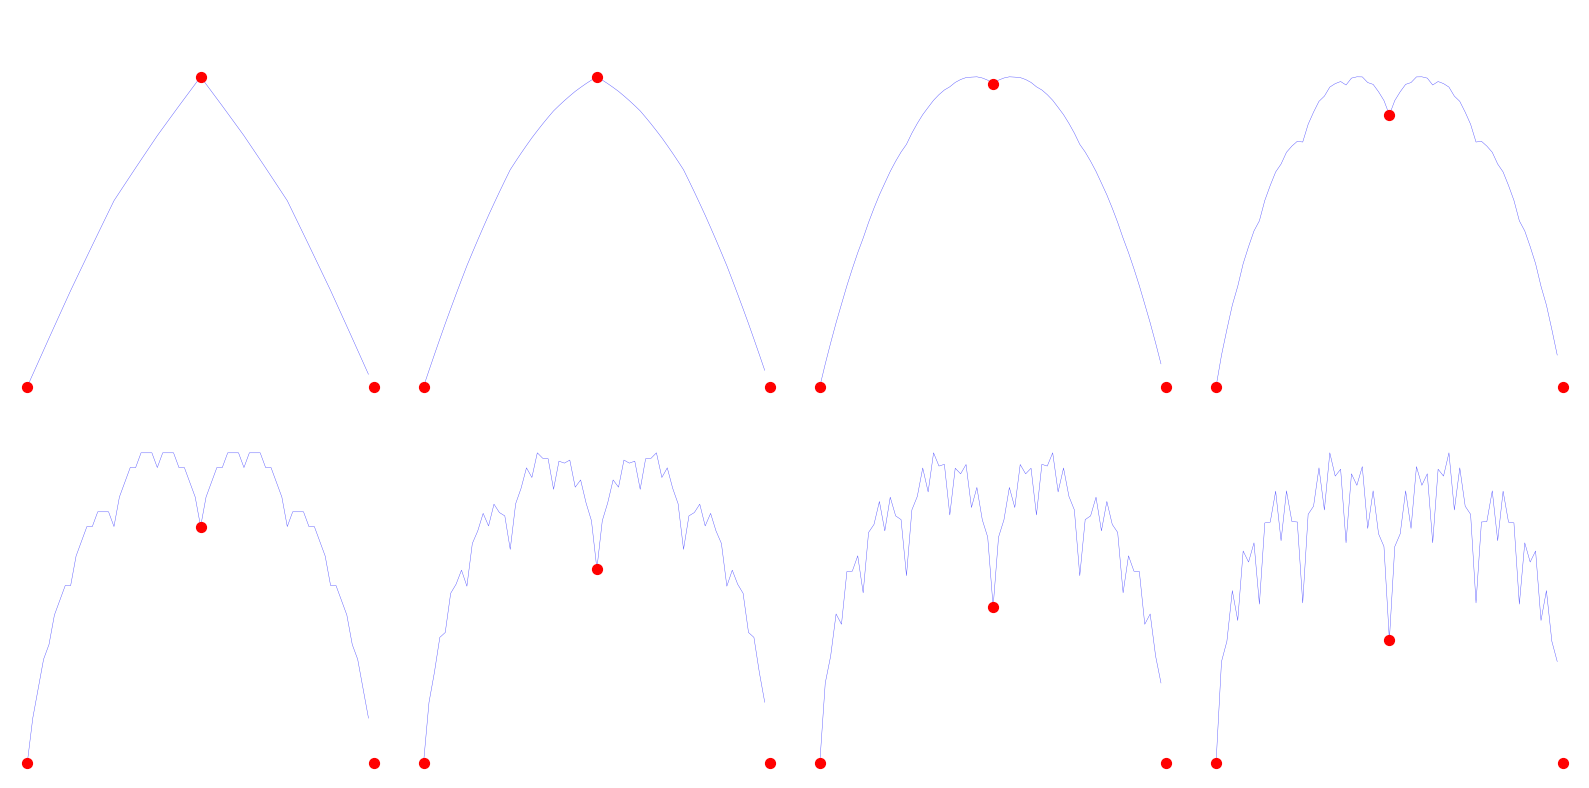

In [39]:
# Szczegółowa analiza wpływu d
d_range = np.linspace(0.1, 0.8, 8)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for ax, d in zip(axes.flat, d_range):
    x, y = simple_fif(data_points, d=d, n_iterations=6)
    ax.plot(x, y, 'b-', linewidth=0.3, alpha=0.7)
    ax.scatter(data_points[:, 0], data_points[:, 1], c='red', s=50, zorder=5)
    ax.set_title(f'd = {d:.2f}')
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle('Wpływ współczynnika skalowania d na strukturę FIF', fontsize=14)
plt.tight_layout()
plt.savefig('../output/figures/fif_d_influence.png', dpi=150)
plt.show()

## 4.3 Ujemne współczynniki skalowania

Ujemne wartości $d$ tworzą inne wzory - funkcja "oscyluje" wokół interpolacji liniowej.

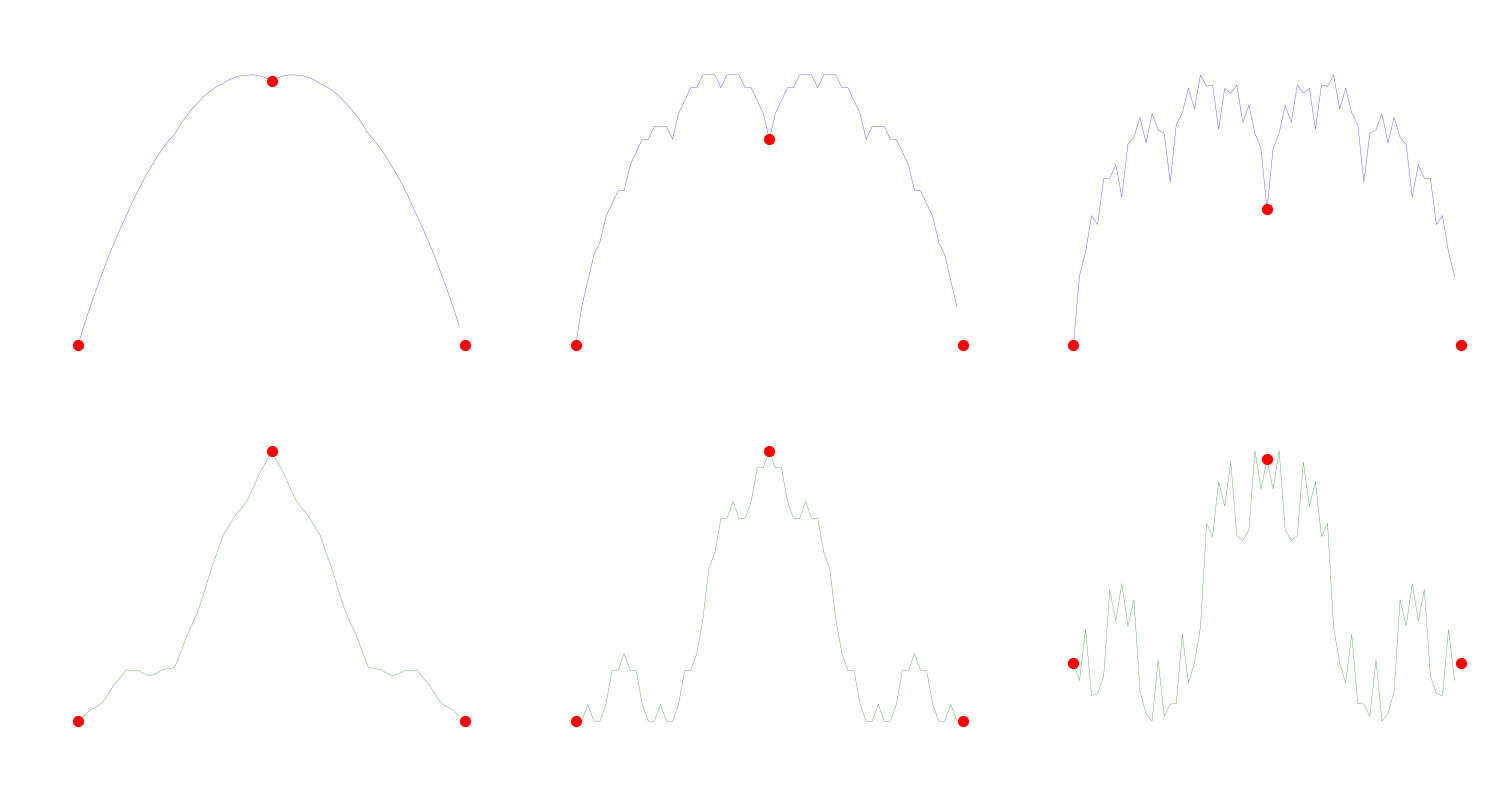

In [40]:
# Porównanie dodatnich i ujemnych d
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
d_values = [0.3, 0.5, 0.7, -0.3, -0.5, -0.7]

for ax, d in zip(axes.flat, d_values):
    x, y = simple_fif(data_points, d=d, n_iterations=6)
    color = 'blue' if d > 0 else 'green'
    ax.plot(x, y, color=color, linewidth=0.3, alpha=0.7)
    ax.scatter(data_points[:, 0], data_points[:, 1], c='red', s=50, zorder=5)
    ax.set_title(f'd = {d}')
    ax.set_xlabel('x')
    ax.set_ylabel('y')

plt.suptitle('Porównanie dodatnich (niebieski) i ujemnych (zielony) współczynników d', fontsize=14)
plt.tight_layout()
plt.savefig('../output/figures/fif_negative_d.png', dpi=150)
plt.show()

## 4.4 FIF z większą liczbą punktów interpolacji

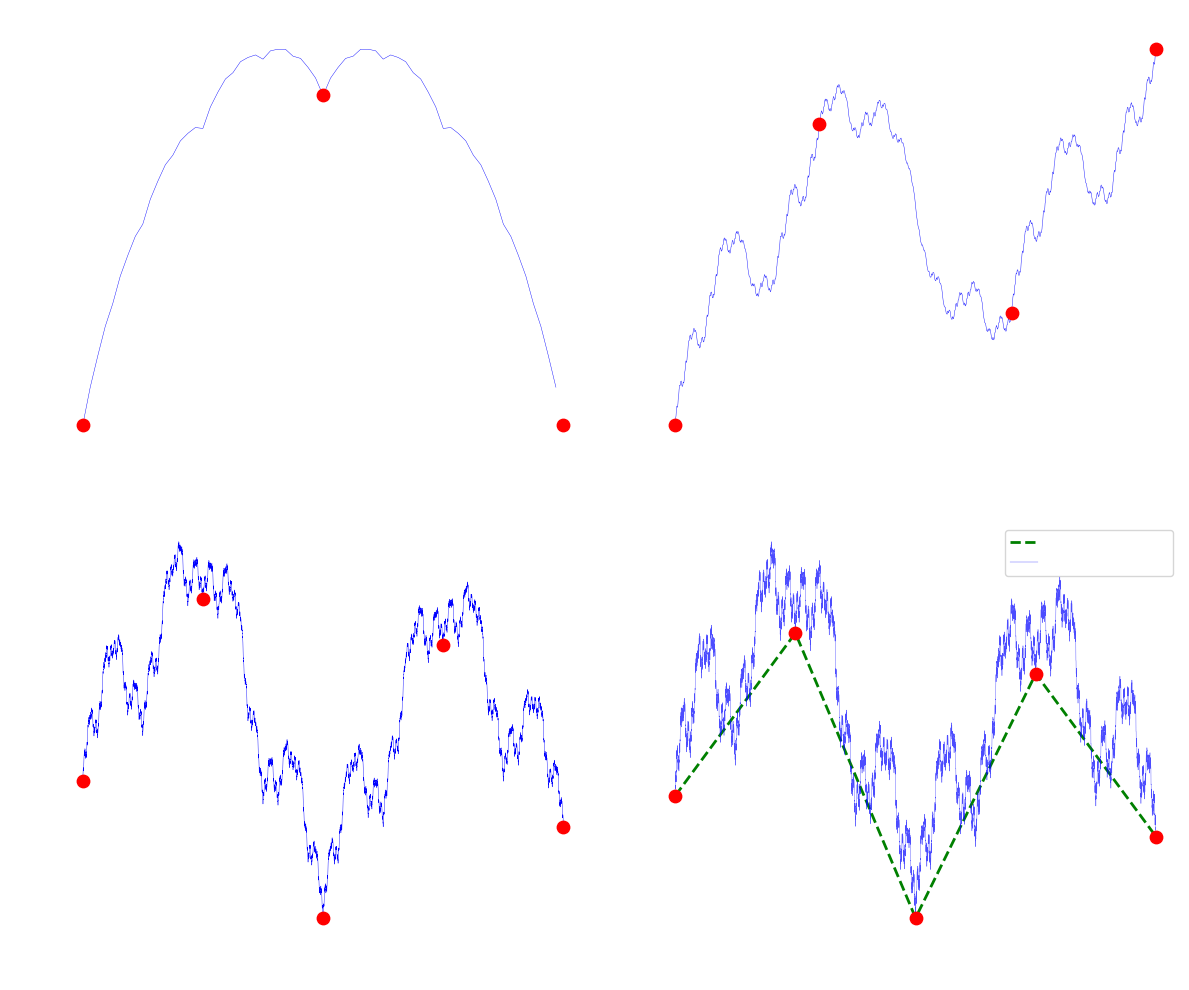

In [41]:
# Więcej punktów interpolacji
data_4points = np.array([
    [0.0, 0.0],
    [0.3, 0.8],
    [0.7, 0.3],
    [1.0, 1.0]
])

data_5points = np.array([
    [0.0, 0.5],
    [0.25, 0.9],
    [0.5, 0.2],
    [0.75, 0.8],
    [1.0, 0.4]
])

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
d = 0.4

# 3 punkty
x, y = simple_fif(data_points, d=d, n_iterations=6)
axes[0, 0].plot(x, y, 'b-', linewidth=0.3)
axes[0, 0].scatter(data_points[:, 0], data_points[:, 1], c='red', s=80, zorder=5)
axes[0, 0].set_title(f'3 punkty interpolacji (d = {d})')

# 4 punkty
x, y = simple_fif(data_4points, d=d, n_iterations=6)
axes[0, 1].plot(x, y, 'b-', linewidth=0.3)
axes[0, 1].scatter(data_4points[:, 0], data_4points[:, 1], c='red', s=80, zorder=5)
axes[0, 1].set_title(f'4 punkty interpolacji (d = {d})')

# 5 punktów
x, y = simple_fif(data_5points, d=d, n_iterations=6)
axes[1, 0].plot(x, y, 'b-', linewidth=0.3)
axes[1, 0].scatter(data_5points[:, 0], data_5points[:, 1], c='red', s=80, zorder=5)
axes[1, 0].set_title(f'5 punktów interpolacji (d = {d})')

# Porównanie z interpolacją liniową
x_lin = np.linspace(0, 1, 1000)
y_lin = np.interp(x_lin, data_5points[:, 0], data_5points[:, 1])
x_fif, y_fif = simple_fif(data_5points, d=0.5, n_iterations=6)

axes[1, 1].plot(x_lin, y_lin, 'g--', linewidth=2, label='Interpolacja liniowa')
axes[1, 1].plot(x_fif, y_fif, 'b-', linewidth=0.3, alpha=0.7, label='FIF (d=0.5)')
axes[1, 1].scatter(data_5points[:, 0], data_5points[:, 1], c='red', s=80, zorder=5)
axes[1, 1].set_title('Porównanie: interpolacja liniowa vs FIF')
axes[1, 1].legend()

for ax in axes.flat:
    ax.set_xlabel('x')
    ax.set_ylabel('y')

plt.tight_layout()
plt.savefig('../output/figures/fif_multipoint.png', dpi=150)
plt.show()

## 4.5 Wymiar fraktalny FIF

Zbadajmy jak wymiar fraktalny FIF zależy od współczynnika skalowania.

In [42]:
# Obliczenie wymiaru teoretycznego
print("Wymiar teoretyczny FIF dla 3 punktów (2 segmenty):")
print("=" * 50)
print("Równanie: 2 * |d|^D = 1")
print("Rozwiązanie: D = -log(2) / log(|d|)")
print()

d_test = [0.3, 0.4, 0.5, 0.6, 0.7]
for d in d_test:
    scaling = np.array([d, d])  # Dwa segmenty z tym samym d
    dim_theo = fif_dimension_theoretical(scaling)
    print(f"d = {d}: D teoretyczne = {dim_theo:.4f}")

Wymiar teoretyczny FIF dla 3 punktów (2 segmenty):
Równanie: 2 * |d|^D = 1
Rozwiązanie: D = -log(2) / log(|d|)

d = 0.3: D teoretyczne = 1.0000
d = 0.4: D teoretyczne = 1.0000
d = 0.5: D teoretyczne = 1.0000
d = 0.6: D teoretyczne = 1.2630
d = 0.7: D teoretyczne = 1.4854


In [43]:
# Porównanie wymiaru teoretycznego z numerycznym
print("\nPorównanie wymiarów teoretycznych i numerycznych:")
print("=" * 60)

d_values = np.array([0.3, 0.4, 0.5, 0.6, 0.7])
dims_theoretical = []
dims_numerical = []

for d in d_values:
    # Teoretyczny
    scaling = np.array([d, d])
    dim_theo = fif_dimension_theoretical(scaling)
    dims_theoretical.append(dim_theo)
    
    # Numeryczny
    x, y = simple_fif(data_points, d=d, n_iterations=7)
    points = curve_to_points(x, y)
    dim_num, r2, _ = box_counting_dimension(points, epsilon_min=0.005, epsilon_max=0.2, n_epsilons=20)
    dims_numerical.append(dim_num)
    
    print(f"d = {d}: D_theo = {dim_theo:.4f}, D_num = {dim_num:.4f}, R² = {r2:.4f}")

dims_theoretical = np.array(dims_theoretical)
dims_numerical = np.array(dims_numerical)


Porównanie wymiarów teoretycznych i numerycznych:
d = 0.3: D_theo = 1.0000, D_num = 0.6234, R² = 0.9185
d = 0.4: D_theo = 1.0000, D_num = 0.6135, R² = 0.9075
d = 0.5: D_theo = 1.0000, D_num = 0.5849, R² = 0.8896
d = 0.6: D_theo = 1.2630, D_num = 0.5423, R² = 0.8628
d = 0.7: D_theo = 1.4854, D_num = 0.4868, R² = 0.8278


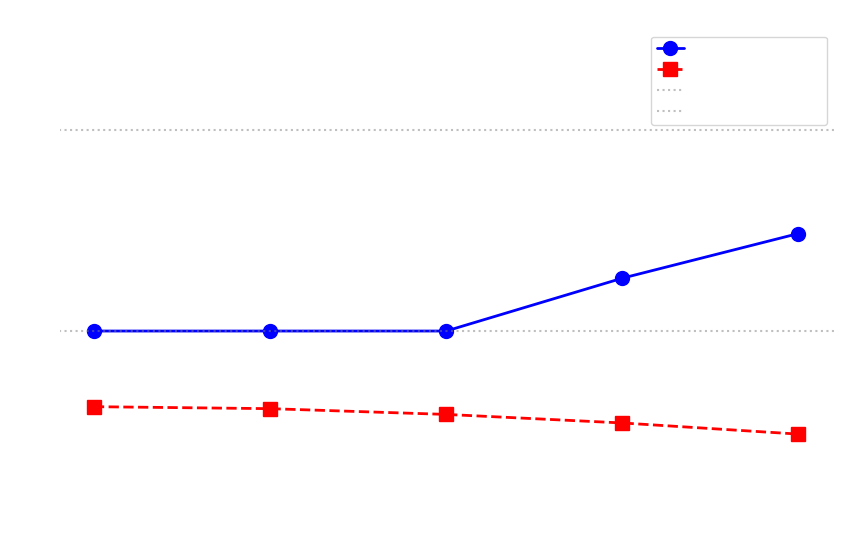

In [44]:
# Wykres zależności wymiaru od d
plt.figure(figsize=(10, 6))
plt.plot(d_values, dims_theoretical, 'b-o', linewidth=2, markersize=10, label='Wymiar teoretyczny')
plt.plot(d_values, dims_numerical, 'r--s', linewidth=2, markersize=10, label='Wymiar numeryczny')
plt.axhline(y=1, color='gray', linestyle=':', alpha=0.5, label='D = 1 (linia)')
plt.axhline(y=2, color='gray', linestyle=':', alpha=0.5, label='D = 2 (płaszczyzna)')
plt.xlabel('Współczynnik skalowania d')
plt.ylabel('Wymiar fraktalny D')
plt.title('Zależność wymiaru FIF od współczynnika skalowania')
plt.legend()
plt.ylim(0.2, 2.5)
plt.grid(True, alpha=0.3)
plt.savefig('../output/figures/fif_dimension_vs_d.png', dpi=150)
plt.show()

## 4.6 Samopodobieństwo FIF

FIF są z definicji samopodobne - każdy segment wygląda jak przeskalowana wersja całości.

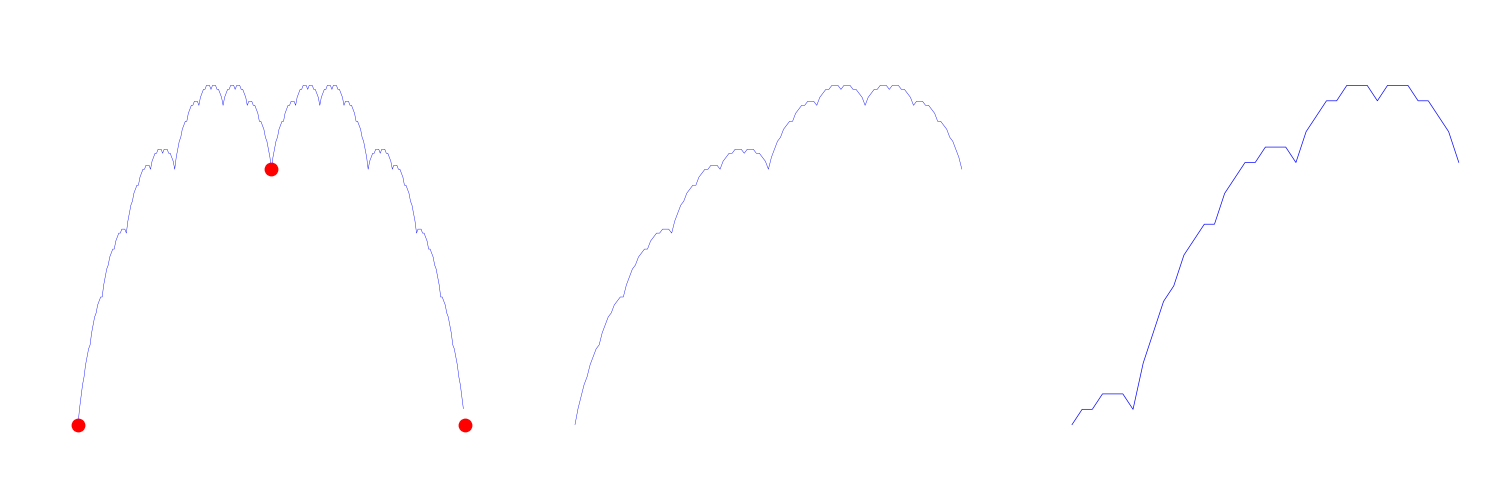

In [45]:
# Demonstracja samopodobieństwa
d = 0.5
x_full, y_full = simple_fif(data_points, d=d, n_iterations=8)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Pełny wykres
axes[0].plot(x_full, y_full, 'b-', linewidth=0.3)
axes[0].scatter(data_points[:, 0], data_points[:, 1], c='red', s=80, zorder=5)
axes[0].set_title('Cała funkcja')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')

# Powiększenie lewej połowy
mask_left = x_full <= 0.5
axes[1].plot(x_full[mask_left], y_full[mask_left], 'b-', linewidth=0.3)
axes[1].set_title('Lewa połowa (x ≤ 0.5)')
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')

# Powiększenie małego fragmentu
mask_small = (x_full >= 0.1) & (x_full <= 0.25)
axes[2].plot(x_full[mask_small], y_full[mask_small], 'b-', linewidth=0.5)
axes[2].set_title('Fragment (0.1 ≤ x ≤ 0.25)')
axes[2].set_xlabel('x')
axes[2].set_ylabel('y')

plt.suptitle(f'Samopodobieństwo FIF (d = {d})', fontsize=14)
plt.tight_layout()
plt.savefig('../output/figures/fif_self_similarity.png', dpi=150)
plt.show()

## 4.7 Zastosowania FIF

FIF mają praktyczne zastosowania w modelowaniu danych o nieregularnej strukturze.

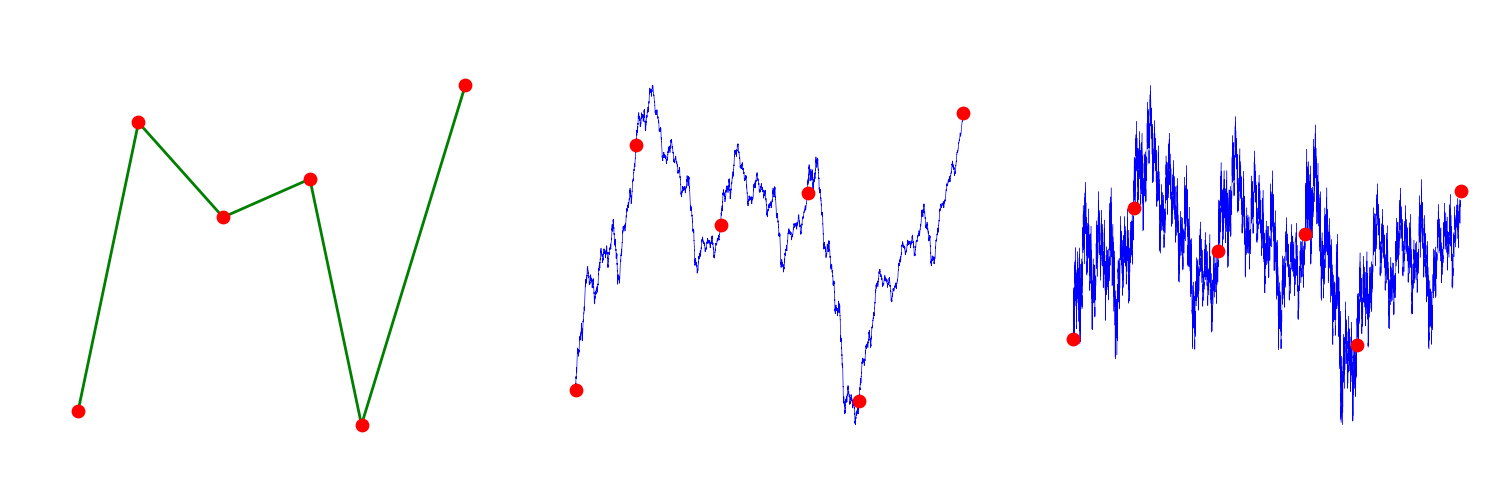

In [46]:
# Przykład: modelowanie nieregularnych danych
# Symulacja danych "naturalnych" (np. linia brzegowa, profil terenu)

np.random.seed(42)
# Generujemy losowe punkty jako "dane pomiarowe"
n_data = 6
x_data = np.sort(np.random.rand(n_data))
x_data[0], x_data[-1] = 0, 1  # Normalizacja
y_data = np.random.rand(n_data)
data_random = np.column_stack([x_data, y_data])

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Interpolacja liniowa
x_lin = np.linspace(0, 1, 1000)
y_lin = np.interp(x_lin, x_data, y_data)
axes[0].plot(x_lin, y_lin, 'g-', linewidth=2)
axes[0].scatter(x_data, y_data, c='red', s=80, zorder=5)
axes[0].set_title('Interpolacja liniowa')

# FIF z małym d
x_fif, y_fif = simple_fif(data_random, d=0.3, n_iterations=6)
axes[1].plot(x_fif, y_fif, 'b-', linewidth=0.5)
axes[1].scatter(x_data, y_data, c='red', s=80, zorder=5)
axes[1].set_title('FIF (d = 0.3) - mała szorstkość')

# FIF z dużym d
x_fif, y_fif = simple_fif(data_random, d=0.6, n_iterations=6)
axes[2].plot(x_fif, y_fif, 'b-', linewidth=0.3)
axes[2].scatter(x_data, y_data, c='red', s=80, zorder=5)
axes[2].set_title('FIF (d = 0.6) - duża szorstkość')

for ax in axes:
    ax.set_xlabel('x')
    ax.set_ylabel('y')

plt.suptitle('Modelowanie nieregularnych danych przy użyciu FIF', fontsize=14)
plt.tight_layout()
plt.savefig('../output/figures/fif_application.png', dpi=150)
plt.show()

## 4.8 Podsumowanie

In [47]:
# Zapisanie wyników
import pandas as pd

results = {
    'd': d_values,
    'D_teoretyczny': dims_theoretical,
    'D_numeryczny': dims_numerical,
    'Błąd (%)': np.abs(dims_numerical - dims_theoretical) / dims_theoretical * 100
}

df = pd.DataFrame(results)
df.to_csv('../output/data/fif_dimensions.csv', index=False)
print("Wyniki zapisane do: output/data/fif_dimensions.csv")
print("\nTabela wyników:")
print(df.to_string(index=False))

Wyniki zapisane do: output/data/fif_dimensions.csv

Tabela wyników:
  d  D_teoretyczny  D_numeryczny  Błąd (%)
0.3       1.000000      0.623382 37.661839
0.4       1.000000      0.613496 38.650391
0.5       1.000000      0.584867 41.513283
0.6       1.263034      0.542318 57.062259
0.7       1.485427      0.486807 67.227803


### Kluczowe wnioski:

1. **Fraktalne funkcje interpolacyjne** pozwalają na tworzenie interpolacji z kontrolowaną "szorstkością".

2. **Współczynnik skalowania d** kontroluje wymiar fraktalny:
   - $d = 0$: interpolacja liniowa ($D = 1$)
   - $|d| \to 1$: coraz bardziej fraktalna struktura ($D \to 2$)

3. **Ujemne wartości d** tworzą inne wzory niż dodatnie przy tym samym |d|.

4. **Zastosowania praktyczne**:
   - Modelowanie linii brzegowych
   - Kompresja obrazów
   - Generowanie tekstur
   - Analiza danych finansowych